In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Step1**:Load and Inspection

In [2]:
df=pd.read_csv(r"C:\Ml_projects\Accident_Prediction\data\traffic_accidents.csv")


In [3]:
df.sample(5)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
14151,01/23/2019 08:20:00 AM,STOP SIGN/FLASHER,SLEET/HAIL,DAYLIGHT,ANGLE,NOT DIVIDED,STRAIGHT AND LEVEL,SNOW OR SLUSH,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,"REPORTED, NOT EVIDENT",2.0,0.0,0.0,0.0,2.0,1.0,8,4,1
136329,06/06/2020 11:45:00 PM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,23,7,6
4832,04/03/2019 01:45:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,13,4,4
108891,06/06/2024 12:00:00 PM,STOP SIGN/FLASHER,UNKNOWN,UNKNOWN,ANGLE,UNKNOWN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,12,5,6
65604,03/14/2017 09:10:00 AM,NO CONTROLS,SNOW,DAYLIGHT,PARKED MOTOR VEHICLE,PARKING LOT,STRAIGHT AND LEVEL,SNOW OR SLUSH,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,9,3,3


In [4]:
print("shape",df.shape)

shape (209306, 24)


There are 209306 rows and 24 columns

In [5]:
print("Columns:- ",df.columns)

Columns:-  Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')


In [6]:
df.dtypes

crash_date                        object
traffic_control_device            object
weather_condition                 object
lighting_condition                object
first_crash_type                  object
trafficway_type                   object
alignment                         object
roadway_surface_cond              object
road_defect                       object
crash_type                        object
intersection_related_i            object
damage                            object
prim_contributory_cause           object
num_units                          int64
most_severe_injury                object
injuries_total                   float64
injuries_fatal                   float64
injuries_incapacitating          float64
injuries_non_incapacitating      float64
injuries_reported_not_evident    float64
injuries_no_indication           float64
crash_hour                         int64
crash_day_of_week                  int64
crash_month                        int64
dtype: object

There are 14 object, 4 int and 6 float columns.

In [7]:
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

There is no missing values in the dataset

In [8]:
print("Duplicates Records:-",df.duplicated().sum())

Duplicates Records:- 31


There are 31 dupliicates records

# **Step2**:Data Cleaning

In [9]:
# Remove Duplicates
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
# Standardize Columns Names
df.columns=df.columns.str.lower().str.replace('-','_').str.replace(' ','_').str.strip()

In [11]:
#fixing the crash_date dtype
df['crash_date']=pd.to_datetime(df['crash_date'],format='%m/%d/%Y %I:%M:%S %p')

In [12]:
df.dtypes

crash_date                       datetime64[ns]
traffic_control_device                   object
weather_condition                        object
lighting_condition                       object
first_crash_type                         object
trafficway_type                          object
alignment                                object
roadway_surface_cond                     object
road_defect                              object
crash_type                               object
intersection_related_i                   object
damage                                   object
prim_contributory_cause                  object
num_units                                 int64
most_severe_injury                       object
injuries_total                          float64
injuries_fatal                          float64
injuries_incapacitating                 float64
injuries_non_incapacitating             float64
injuries_reported_not_evident           float64
injuries_no_indication                  

In [13]:
df.head(2)

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8


In [14]:
df['damage'].value_counts()

damage
OVER $1,500      147294
$501 - $1,500     41203
$500 OR LESS      20778
Name: count, dtype: int64

In [15]:
mapping={
    'OVER $1,500':2,
    '$501 - $1,500':1,
    '$500 OR LESS':0
}
df['damage']=df['damage'].map(mapping)

# **Step3**:Feature Selection And Sepration

In [16]:
Numerical_Features=df.select_dtypes(['int','float'])
Categorical_Features=df.select_dtypes(['object'])

# **Step4**:Univariate Analysis

In [17]:
df.describe()

,crash_date,damage,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209275,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000
mean,2020-12-08 23:18:07.071556096,1.604544,2.063299,0.382707,0.001859,0.038103,0.221226,0.121520,2.244019,13.372897,4.144045,6.771798
min,2013-03-03 16:48:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2018-12-03 10:12:30,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2020-12-19 17:15:00,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2023-01-08 01:30:00,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,2025-01-18 00:17:00,2.000000,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000
std,NaN,0.661547,0.396030,0.799720,0.047505,0.233971,0.614939,0.450884,1.241159,5.604019,1.966880,3.427626


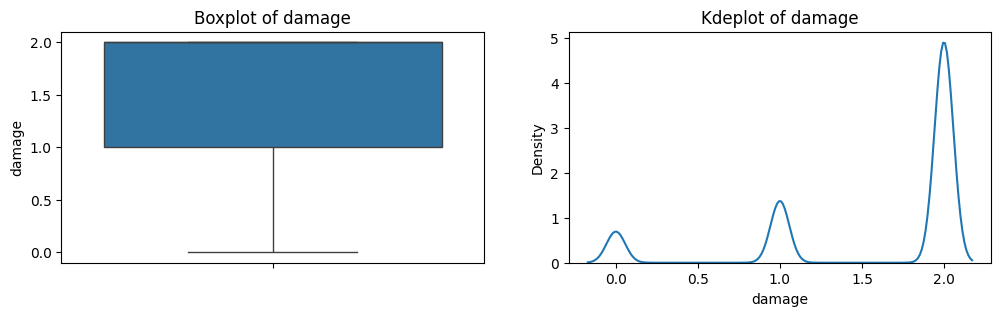

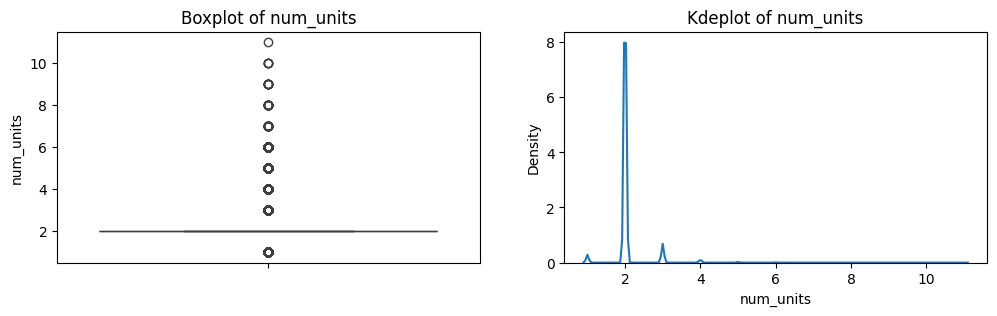

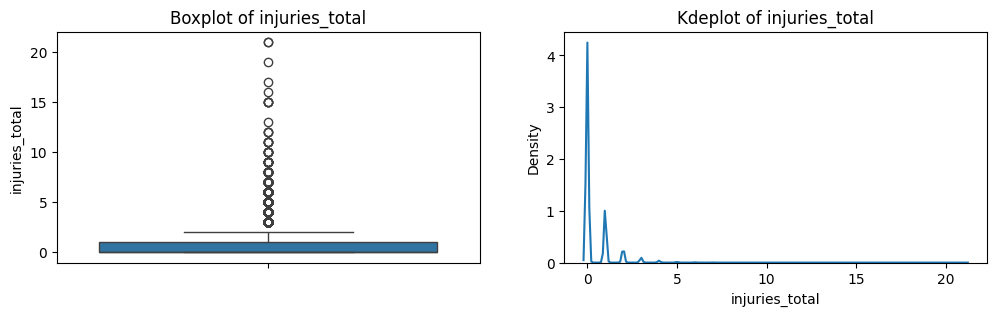

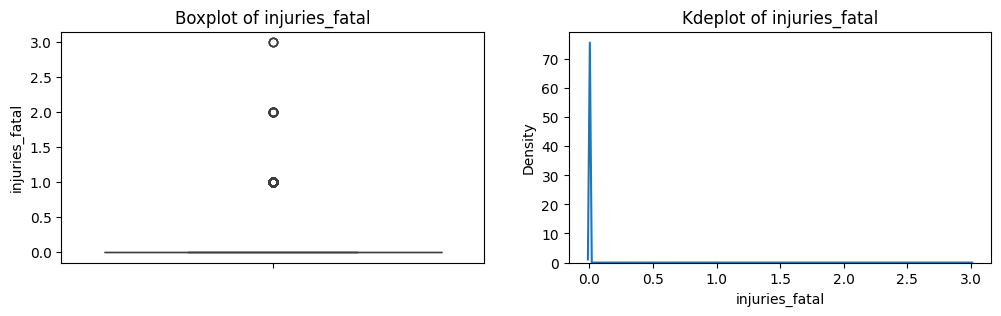

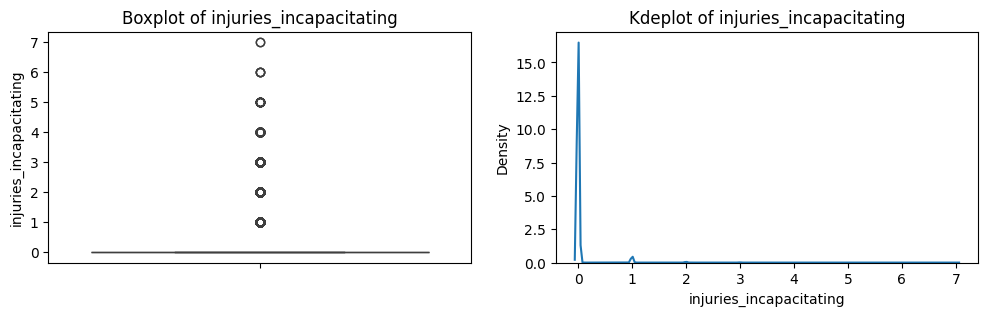

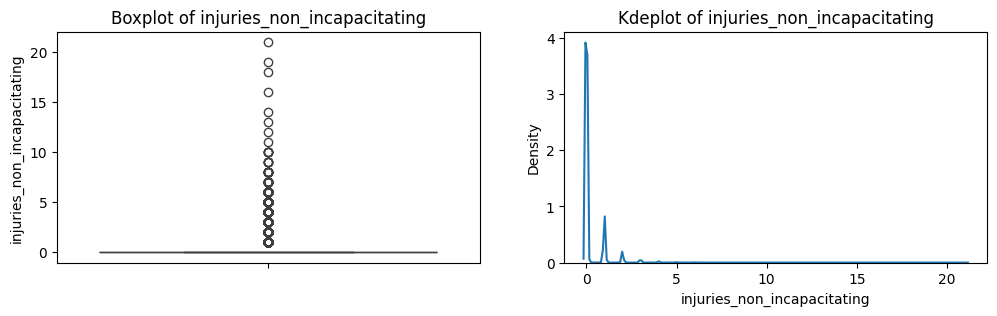

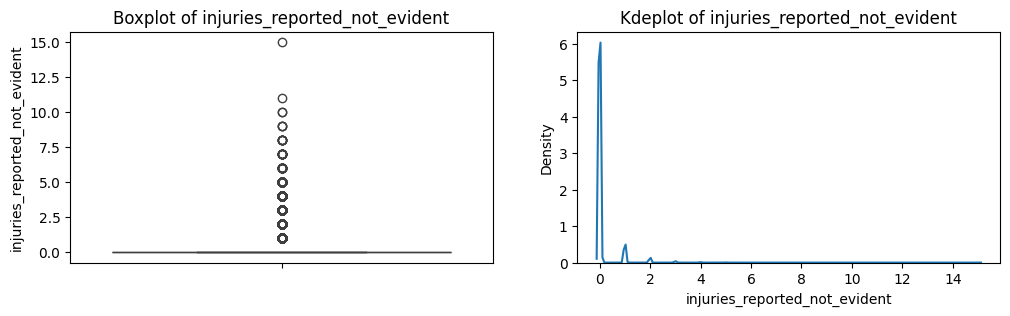

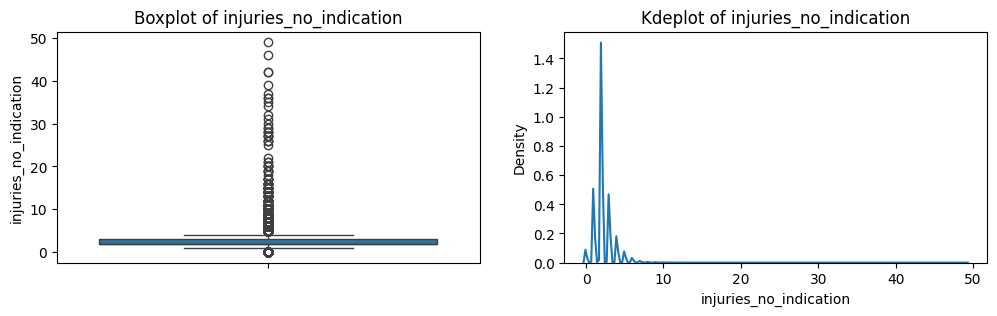

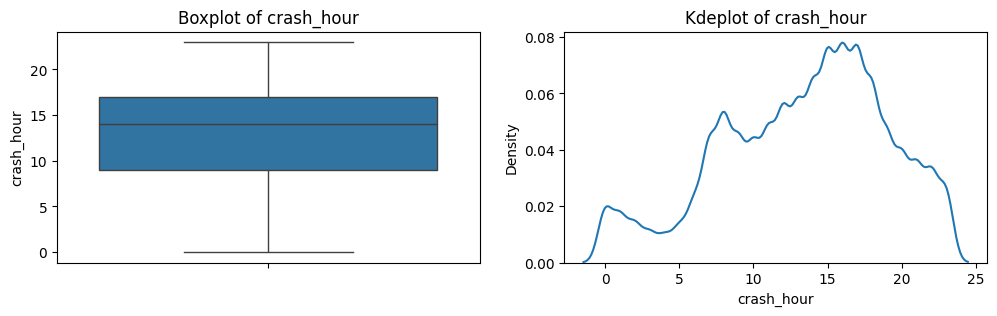

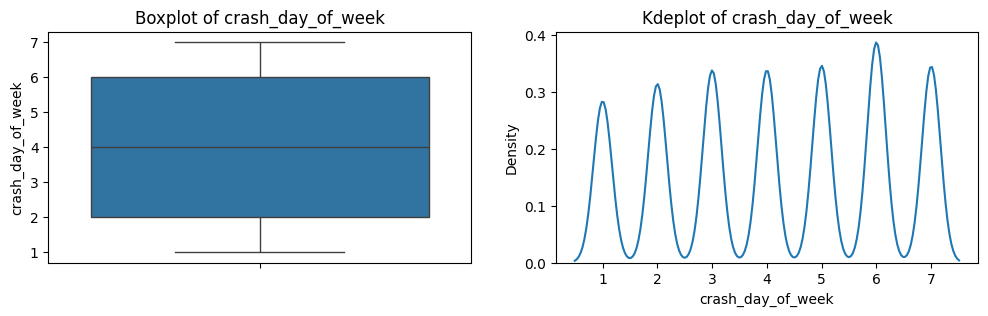

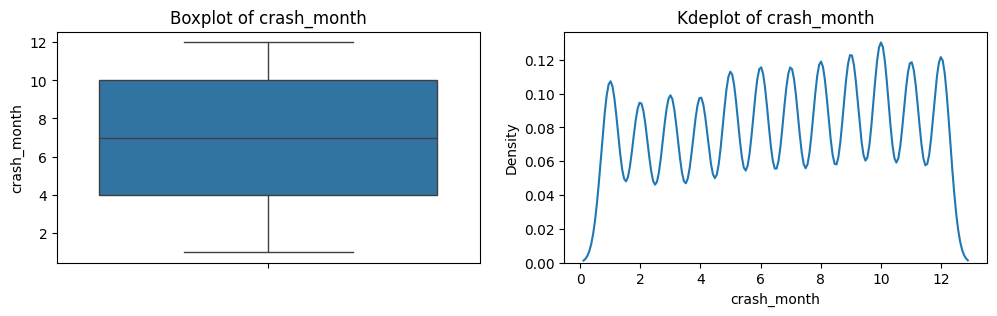

In [18]:
# Numerical  Distribution
for i in Numerical_Features:
    plt.figure(figsize=(12,3))
    
    plt.subplot(1,2,1)
    sns.boxplot(df[i])
    plt.title(f"Boxplot of {i}")

    plt.subplot(1,2,2)
    sns.kdeplot(df[i])
    plt.title(f"Kdeplot of {i}")

    plt.show()

In [19]:
def categorical_dist(df,columns):
    for i in columns:
        plt.figure(figsize=(12,5))

        sns.countplot(data=df, x=i, order=df[i].value_counts().index)
        
        plt.title(f'Distribution of {i}')
        plt.xticks(rotation=90,fontsize=8)
        plt.tight_layout()
        plt.show()

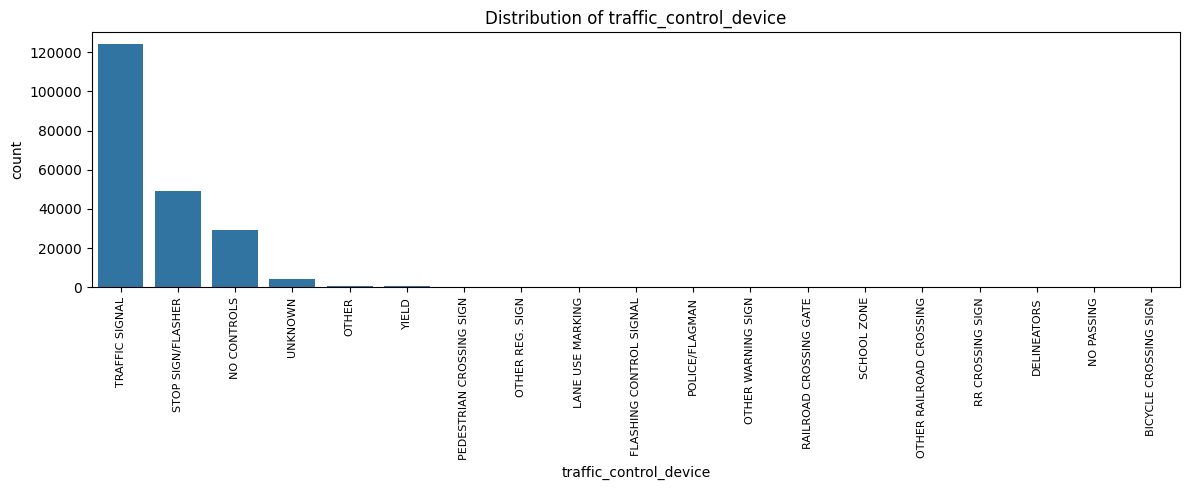

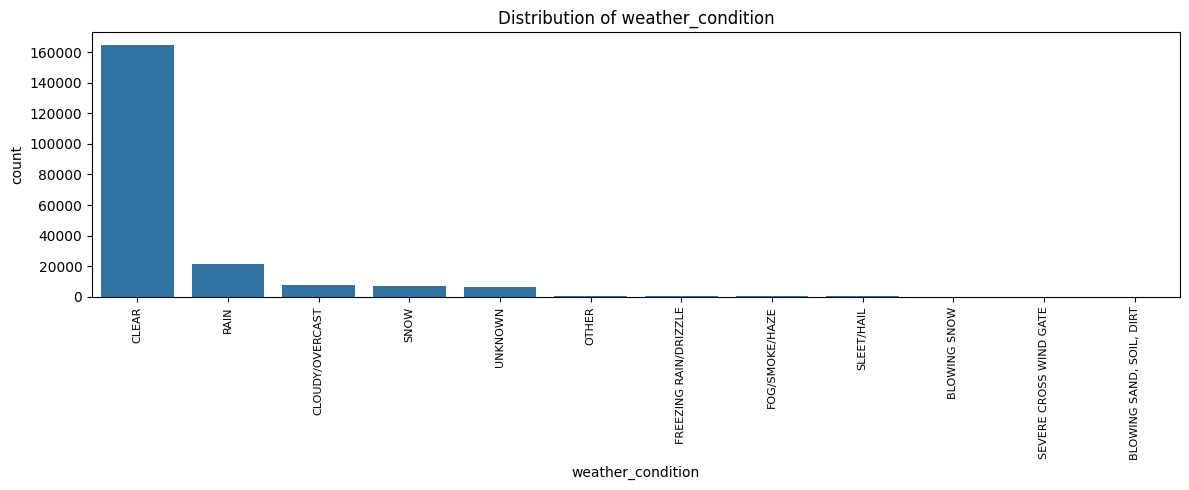

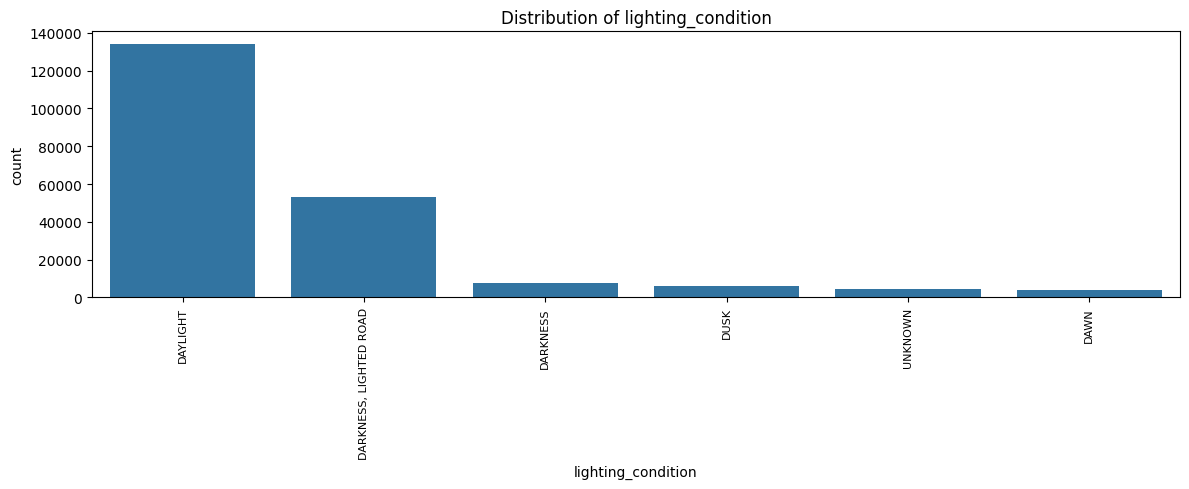

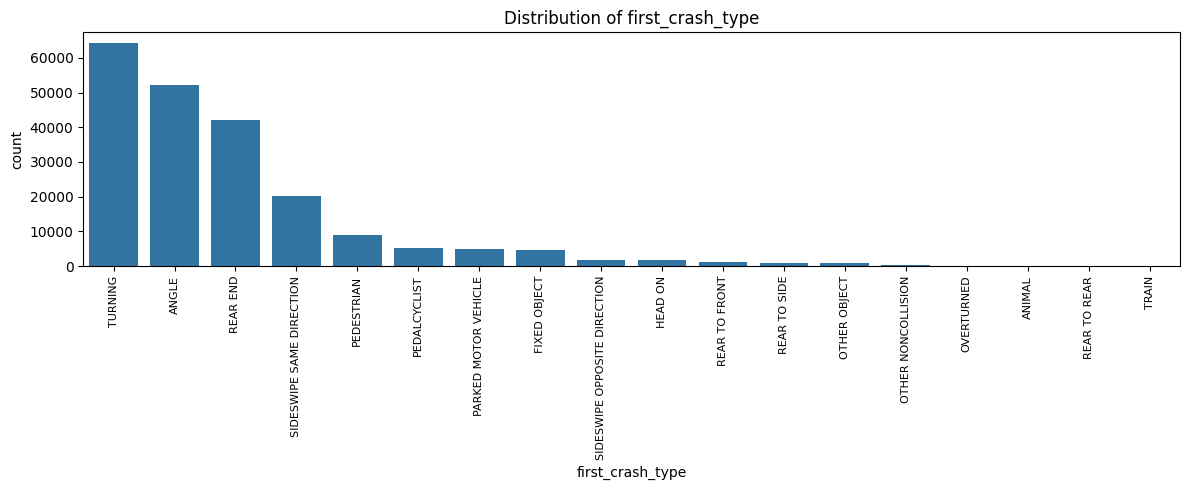

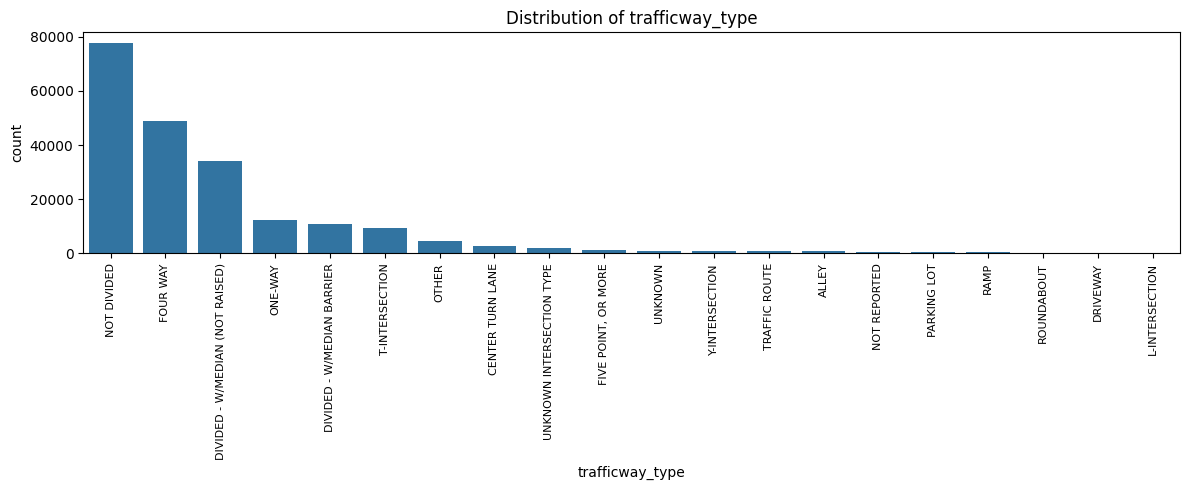

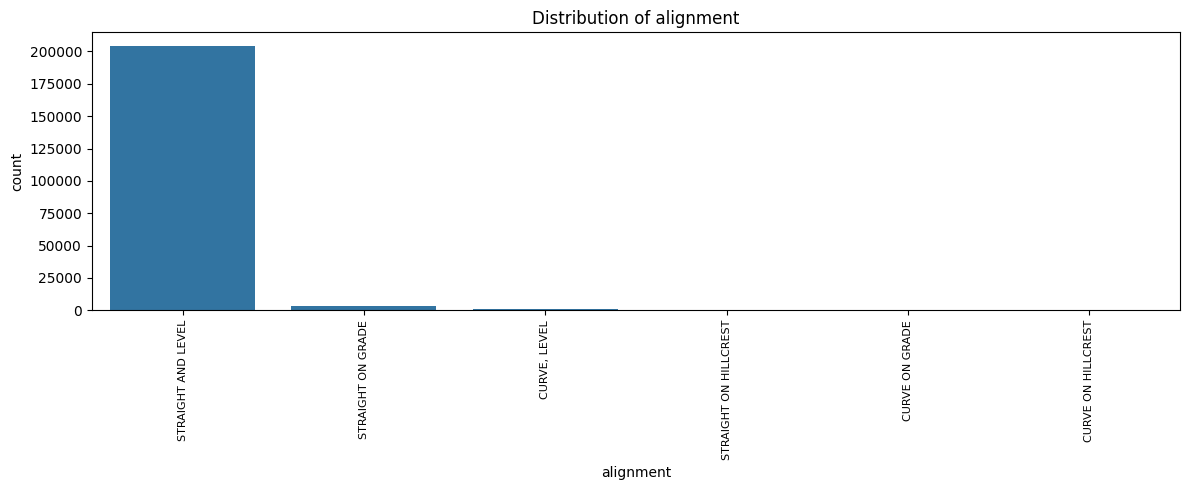

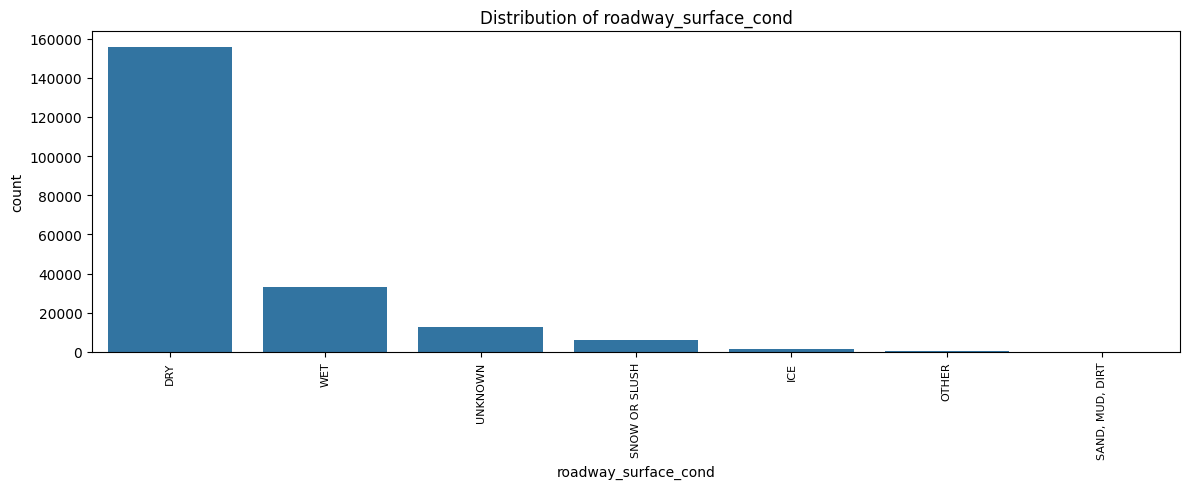

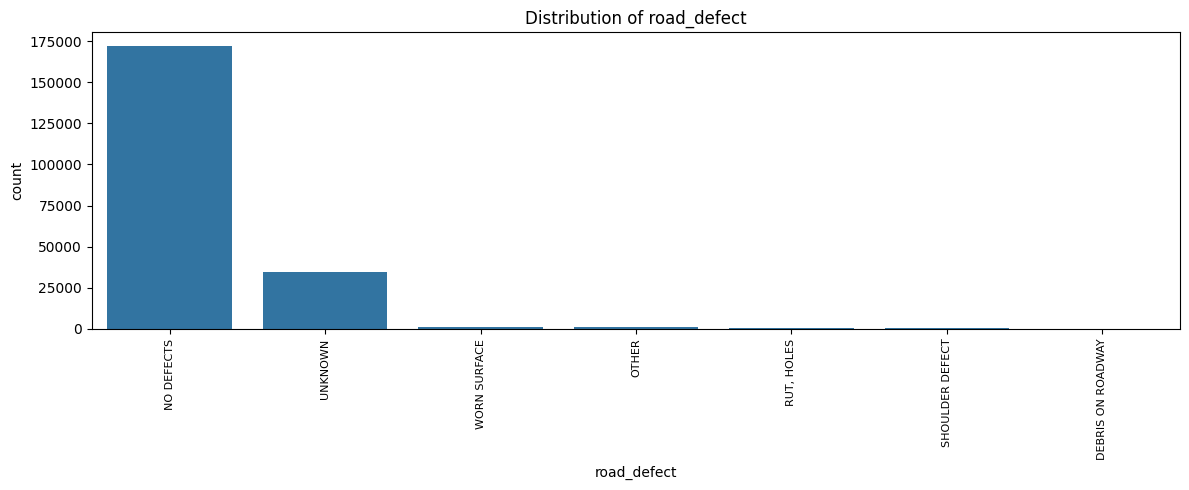

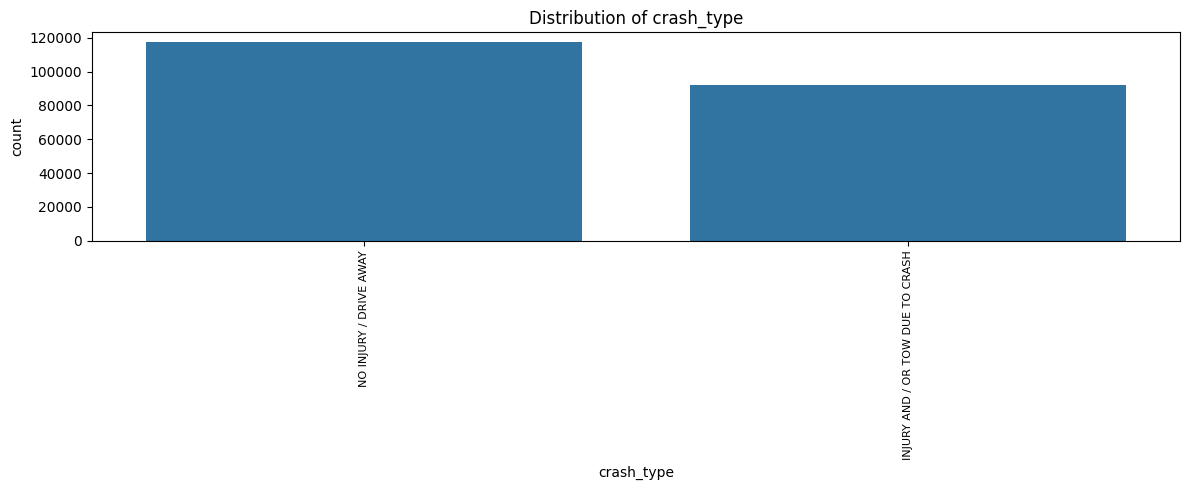

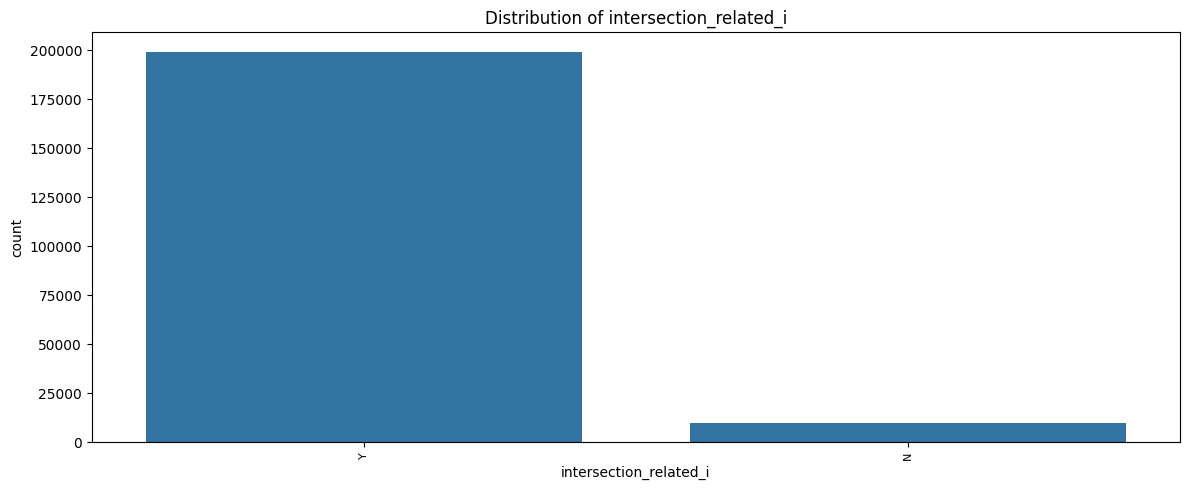

C:\Users\P\AppData\Local\Temp\ipykernel_32048\869013189.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


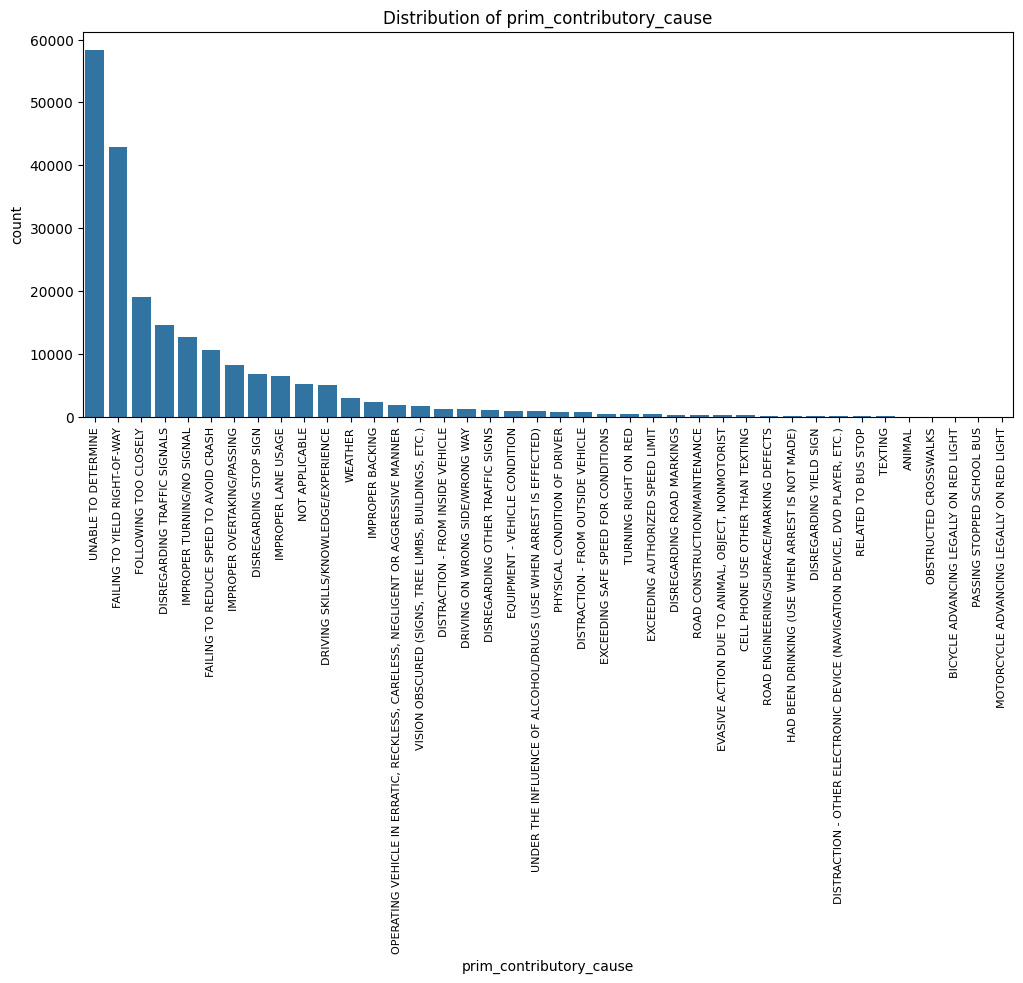

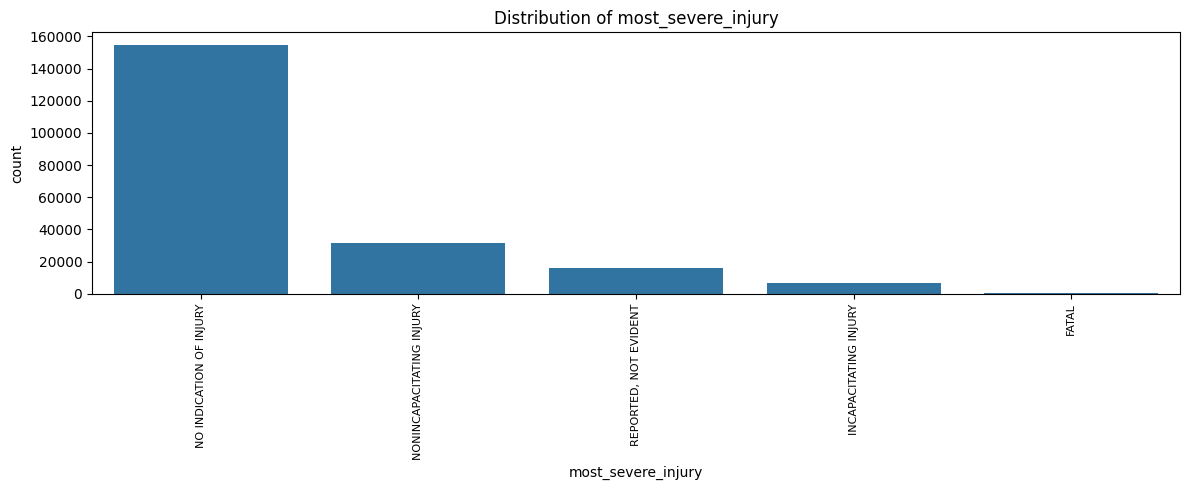

In [20]:
categorical_dist(df,Categorical_Features)

**Bivariate Analysis**

In [21]:
x=df.groupby(['trafficway_type'])['injuries_total'].sum().sort_values(ascending=False)
px.bar(x,title="Total Injuries By Traffic Type")


In [22]:
z=df.groupby(['weather_condition'])['injuries_total'].sum().sort_values(ascending=False)
px.bar(z,title="Total Injuries By Weather conditions")

In [23]:
road_surface=df.groupby(['roadway_surface_cond'])['injuries_total'].sum().sort_values(ascending=False)

In [24]:
px.bar(road_surface,title="Injuries By Road Surface",orientation='h')

In [25]:
monthly_injuries=df.groupby('crash_month')['injuries_total'].sum().reset_index()

In [26]:
monthly_injuries=monthly_injuries.sort_values('crash_month')

In [27]:
px.line(monthly_injuries,x='crash_month',y='injuries_total',title="Monthly Injuries")

**Multivariate Analysis**

In [28]:
p=df.groupby(['lighting_condition','first_crash_type'])['injuries_total'].sum().sort_values(ascending=False).reset_index()
p

,lighting_condition,first_crash_type,injuries_total
0,DAYLIGHT,ANGLE,17229.0
1,DAYLIGHT,TURNING,13098.0
2,"DARKNESS, LIGHTED ROAD",ANGLE,9371.0
3,"DARKNESS, LIGHTED ROAD",TURNING,6407.0
4,DAYLIGHT,REAR END,6262.0
...,...,...,...
96,DAWN,TRAIN,0.0
97,DAWN,REAR TO REAR,0.0
98,DAWN,OVERTURNED,0.0
99,UNKNOWN,OTHER NONCOLLISION,0.0


In [29]:
top10 = p.head(10)
px.bar(top10,x='injuries_total',y='first_crash_type',color='lighting_condition',orientation='h',title='Top 10 Crash Scenarios')

In [30]:
Q=df.groupby(['traffic_control_device','roadway_surface_cond'])['injuries_total'].sum().sort_values(ascending=False).reset_index()
top5=Q.head(5)

In [31]:
px.bar(top5,x='injuries_total',y='traffic_control_device',color='roadway_surface_cond',orientation='h',title='Top 5 Crash Scenarios')

In [32]:
corelation=Numerical_Features.corr()

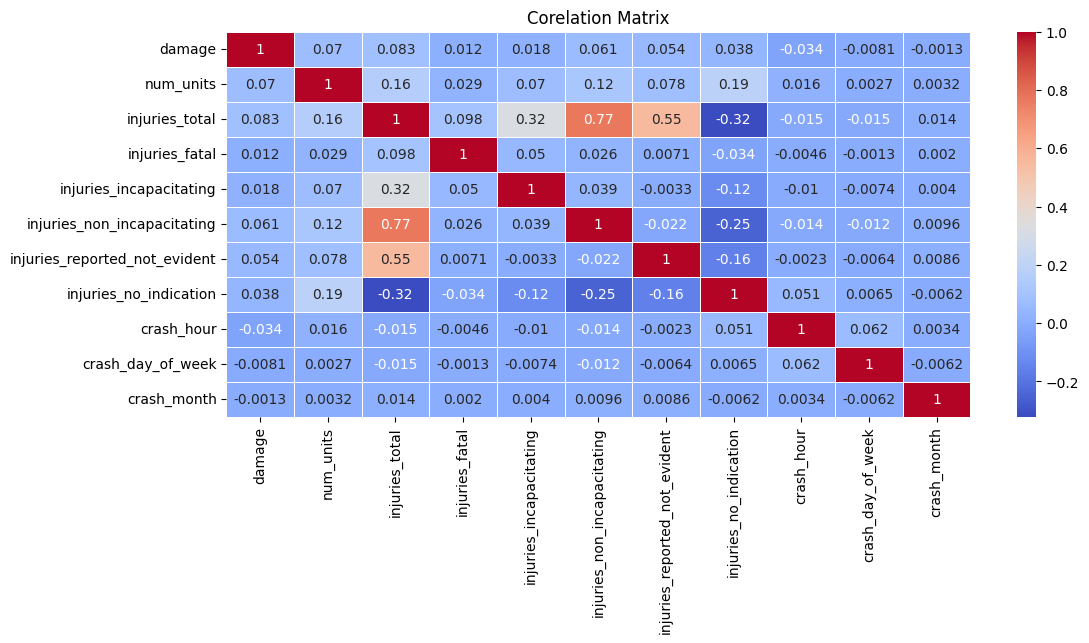

In [36]:
plt.figure(figsize=(12,5))
sns.heatmap(corelation,annot=True,linewidths=0.5,cmap='coolwarm')
plt.title("Corelation Matrix")
plt.show()

When total injuries increase, non-serious injuries also increase a lot.More total injuries → more minor/hidden injuries reported.Serious injuries also rise with total injuries, but not as strongly